# 星像入り画像1枚でのpixelズレ検証

機器接続・冷却・露光・MoT送信は行いません。`src`の画像解析関数を直接実行します。

`.config` の `pixel_test_slit_mode = "science"` では、`test_sigmagem_nearby_slit.fit` **1枚だけ**からスリットと点源を検出します。`test_00.fits` は読み込みません。

- 画像：`pixel_test_image_path`
- スリット領域：`pixel_test_slit_roi`（スリット全体を含み、左の遮蔽領域を除外）
- 座標：0始まり、x=列、y=行。表示は `origin="lower"`。
- 補正方向のズレ：**スリット中心 − 点源中心**。
- スリット中心は、検出された暗い断片を直線で結び、その両端の中点として推定します。

飽和した星像やスリットの隠れた部分があるため、中心は推定値です。マスク・直線・端点の可視化とパラメーター感度を確認してください。`reference` モードは以前の2画像方式です。

In [1]:
from pathlib import Path
import os
import sys
import tomllib
import json

# notebookのフォルダ、observation、またはworkspaceから実行可能
ROOT = None
for base in (Path.cwd(), *Path.cwd().parents):
    for relative in (Path('.'), Path('scat_guide_tracking_system'),
                     Path('scat_observation/scat_guide_tracking_system'),
                     Path('observation/scat_observation/scat_guide_tracking_system'),
                     Path('tsuboi_lab/observation/scat_observation/scat_guide_tracking_system')):
        candidate = base / relative
        if (candidate / 'src/base__point_detector.py').is_file() and (candidate / '.config').is_file():
            ROOT = candidate.resolve()
            break
    if ROOT is not None:
        break
assert ROOT is not None, 'プロジェクトが見つかりません'
sys.path.insert(0, str(ROOT))
os.environ.setdefault('MPLCONFIGDIR', str(ROOT / 'test_all/.mplconfig'))

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from astropy.io import fits
from IPython.display import display, Markdown
from src.base__fits_utils import read_image
from src.base__point_detector import detect_slit, slit_center, detect_science_slit, point_sources, pixel_offset

config = tomllib.loads((ROOT / '.config').read_text(encoding='utf-8'))
source_path = ROOT / config['pixel_test_image_path']
mode = config['pixel_test_slit_mode']
assert mode in ('science', 'reference')
science_image = mode == 'science'
reference_path = source_path if science_image else ROOT / config['flat_path']
roi = config['pixel_test_slit_roi'] if science_image else config['slit_roi']
print('Python:', sys.executable)
print('スリット検出:', reference_path)
print('点源検出:', source_path)
print('ROI [x0,y0,x1,y1]:', roi)

Python: C:\Users\hiroki.kawai\work\04_workspace\tsuboi_lab\observation\.venv\Scripts\python.exe
スリット検出: C:\Users\hiroki.kawai\work\04_workspace\tsuboi_lab\observation\scat_observation\scat_guide_tracking_system\pictures\02_slit_guide_images\test_sigmagem_nearby_slit.fit
点源検出: C:\Users\hiroki.kawai\work\04_workspace\tsuboi_lab\observation\scat_observation\scat_guide_tracking_system\pictures\02_slit_guide_images\test_sigmagem_nearby_slit.fit
ROI [x0,y0,x1,y1]: [880, 250, 1130, 850]


## 1. FITS読み込み

scienceモードでは同じ画像配列を使用します。元画像は変更せず、別のフラット画像にはアクセスしません。

In [2]:
source_image = read_image(source_path)
reference = source_image if science_image else read_image(reference_path)
assert reference.shape == source_image.shape, '画像サイズが異なります。座標変換が必要です'
print('画像サイズ (height, width):', reference.shape)
for path in (reference_path, source_path):
    header = fits.getheader(path)
    print(path.name, {key: header.get(key, '未記録') for key in
                     ('EXPTIME', 'XBINNING', 'YBINNING', 'XORGSUBF', 'YORGSUBF')})
print('同一画像による検証' if science_image else '注意: 2画像の位置合わせは未確認')

画像サイズ (height, width): (1039, 1391)
test_sigmagem_nearby_slit.fit {'EXPTIME': 0.5, 'XBINNING': 1, 'YBINNING': 1, 'XORGSUBF': 0, 'YORGSUBF': 0}
test_sigmagem_nearby_slit.fit {'EXPTIME': 0.5, 'XBINNING': 1, 'YBINNING': 1, 'XORGSUBF': 0, 'YORGSUBF': 0}
同一画像による検証


## 2. srcで星像とスリットを分離して検出

スリット用処理では、明るい画素の値を制限して星像が閾値を支配するのを抑え、平滑化でノイズを減らします。細長い暗領域のうち向き・位置がそろった断片を結び、直線と両端を推定します。星の重心計算には加工前の画像を使用します。

最大5個の点源候補から設定された明るさ順位を選択します。候補には星の周辺構造が含まれる場合があります。

In [3]:
detection = detect_slit(reference, roi, science_image=science_image)
slit_xy = slit_center(reference, roi, science_image=science_image)
np.testing.assert_allclose(slit_xy, detection['center'])
sources = point_sources(source_image, threshold_sigma=config['threshold_sigma'], max_sources=5)
rank = config['target_brightness_rank']
assert len(sources) >= rank, '指定順位の点源が検出されません'
target = sources[rank - 1]
star_xy = np.array([target['x'], target['y']])
print('候補順位 | x [px] | y [px] | background-subtracted flux')
for i, item in enumerate(sources, 1):
    print(f"{i:8d} | {item['x']:9.3f} | {item['y']:9.3f} | {item['flux']:.1f}")
print('選択順位:', rank)
print('スリット中心:', slit_xy)
print('点源中心:', star_xy)
saturated_count = int(np.count_nonzero(source_image >= 65535))
print('65535 ADU以上の画素数:', saturated_count)
print('点源は飽和しているため、重心の小数桁は測定精度を保証しません。')

候補順位 | x [px] | y [px] | background-subtracted flux
       1 |   994.712 |   538.253 | 3640170.0
       2 |   969.038 |   527.208 | 71857.0
       3 |   970.950 |   539.386 | 35641.0
       4 |  1020.940 |   544.971 | 10001.0
       5 |   526.554 |   541.176 | 6550.0
選択順位: 1
スリット中心: [1007.11355264  564.27636023]
点源中心: [994.71248266 538.25349695]
65535 ADU以上の画素数: 31
点源は飽和しているため、重心の小数桁は測定精度を保証しません。


## 3. pixelズレの計算

RA/Dec変換・補正係数更新・通信は実行しません。符号を明示するため両方向を表示します。

In [4]:
offset = pixel_offset(star_xy, slit_xy)
distance = float(np.linalg.norm(offset))
assert np.isfinite(offset).all()
assert len(sources) <= 5
np.testing.assert_allclose(star_xy + offset, slit_xy)
results = {
    'reference_image': reference_path.name,
    'source_image': source_path.name,
    'coordinate_convention': 'zero-based x=column, y=row; offset=slit-source',
    'slit_roi': roi,
    'slit_xy_px': slit_xy.tolist(),
    'source_xy_px': star_xy.tolist(),
    'slit_minus_source_px': offset.tolist(),
    'source_minus_slit_px': (-offset).tolist(),
    'distance_px': distance,
    'saturated_pixels_ge_65535': saturated_count,
    'same_image': science_image,
    'slit_center_definition': 'detected endpoint midpoint' if science_image else 'mask centroid',
}
display(Markdown(f'''
| 項目 | x [pixel] | y [pixel] |
|---|---:|---:|
| スリット中心 | {slit_xy[0]:.3f} | {slit_xy[1]:.3f} |
| 点源中心 | {star_xy[0]:.3f} | {star_xy[1]:.3f} |
| スリット − 点源（補正方向） | {offset[0]:+.3f} | {offset[1]:+.3f} |
| 点源 − スリット | {-offset[0]:+.3f} | {-offset[1]:+.3f} |

距離：**{distance:.3f} pixel**（同一画像内の推定中心差。referenceモード時は2画像の座標差）。
'''))


| 項目 | x [pixel] | y [pixel] |
|---|---:|---:|
| スリット中心 | 1007.114 | 564.276 |
| 点源中心 | 994.712 | 538.253 |
| スリット − 点源（補正方向） | +12.401 | +26.023 |
| 点源 − スリット | -12.401 | -26.023 |

距離：**28.827 pixel**（同一画像内の推定中心差。referenceモード時は2画像の座標差）。


## 4. 可視化

左：検出用ROIとスリット推定位置。右：点源からスリット中心へのpixelズレ。
scienceモードでは同じ1枚を表示します。星像の付近でスリットが分断されていても、両側の暗い構造から位置を推定します。

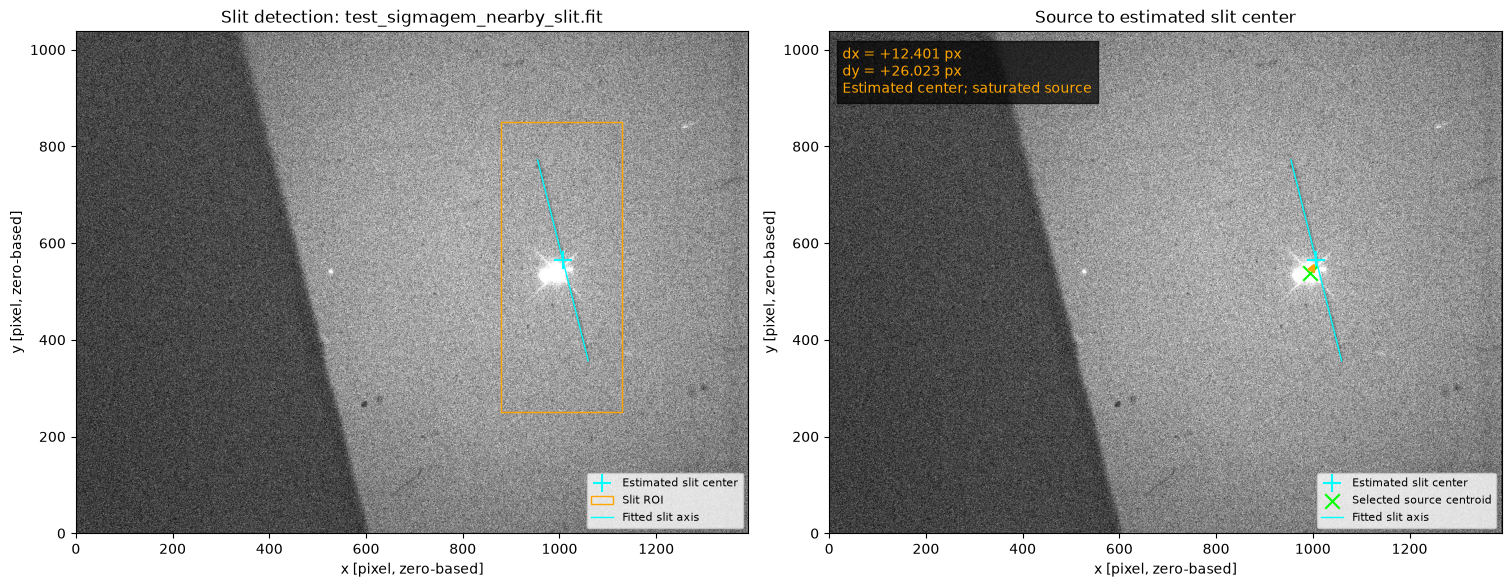

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6), constrained_layout=True)
for ax, image, title in zip(axes, (reference, source_image),
                            ('Slit detection: ' + reference_path.name, 'Source to estimated slit center')):
    lo, hi = np.percentile(image, [1, 99])
    ax.imshow(image, origin='lower', cmap='gray', vmin=lo, vmax=hi)
    ax.set(title=title, xlabel='x [pixel, zero-based]', ylabel='y [pixel, zero-based]')
    ax.scatter(*slit_xy, marker='+', s=180, color='cyan', label='Estimated slit center')
x0,y0,x1,y1 = roi
axes[0].add_patch(Rectangle((x0,y0), x1-x0, y1-y0, fill=False, edgecolor='orange', label='Slit ROI'))
axes[1].scatter(*star_xy, marker='x', s=110, color='lime', label='Selected source centroid')
axes[1].annotate('', xy=slit_xy, xytext=star_xy, arrowprops=dict(arrowstyle='->', color='orange', lw=2))
axes[1].text(.02,.97, f'dx = {offset[0]:+.3f} px\ndy = {offset[1]:+.3f} px\nEstimated center; saturated source',
             transform=axes[1].transAxes, va='top', color='orange', bbox=dict(facecolor='black', alpha=.7))
if science_image:
    for ax in axes:
        ends = detection['endpoints']
        ax.plot(ends[:,0], ends[:,1], color='cyan', lw=1, label='Fitted slit axis')
for ax in axes:
    ax.legend(loc='lower right', fontsize=8)
output_dir = ROOT / 'test_all/pixel_offset_results'
output_dir.mkdir(exist_ok=True)
fig.savefig(output_dir / 'pixel_offset_nearby_slit.png', dpi=150)
plt.show()

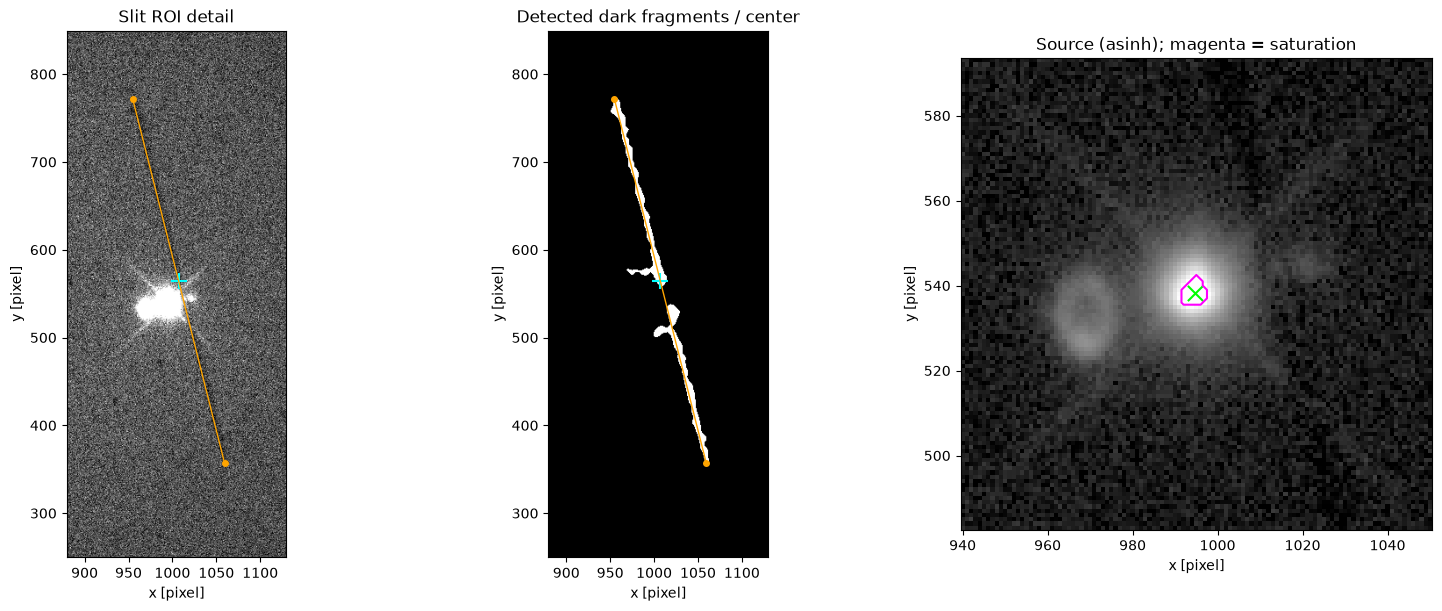

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6), constrained_layout=True)
crop = reference[y0:y1,x0:x1]
axes[0].imshow(crop, origin='lower', extent=(x0-.5,x1-.5,y0-.5,y1-.5), cmap='gray',
               vmin=np.percentile(crop,1), vmax=np.percentile(crop,99))
axes[0].scatter(*slit_xy, marker='+', color='cyan', s=140)
axes[0].set_title('Slit ROI detail')
axes[1].imshow(detection['mask'], origin='lower', extent=(x0-.5,x1-.5,y0-.5,y1-.5), cmap='gray')
axes[1].scatter(*slit_xy, marker='+', color='cyan', s=140)
axes[1].set_title('Detected dark fragments / center')
if science_image:
    ends = detection['endpoints']
    for ax in axes[:2]:
        ax.plot(ends[:,0],ends[:,1],color='orange',marker='o',ms=4,lw=1)
x,y = np.rint(star_xy).astype(int)
r = 55
sx0,sx1 = max(0,x-r), min(source_image.shape[1],x+r+1)
sy0,sy1 = max(0,y-r), min(source_image.shape[0],y+r+1)
star_crop = source_image[sy0:sy1,sx0:sx1]
axes[2].imshow(np.arcsinh(np.maximum(star_crop-np.median(source_image),0)/30), origin='lower',
               extent=(sx0-.5,sx1-.5,sy0-.5,sy1-.5), cmap='gray')
axes[2].scatter(*star_xy, color='lime', marker='x', s=120)
axes[2].contour(np.arange(sx0,sx1),np.arange(sy0,sy1),star_crop>=65535, levels=[.5],colors='magenta')
axes[2].set_title('Source (asinh); magenta = saturation')
for ax in axes:
    ax.set_xlabel('x [pixel]')
    ax.set_ylabel('y [pixel]')
fig.savefig(output_dir / 'pixel_detection_details.png', dpi=150)
plt.show()

## 5. パラメーター感度と確認結果

閾値を変更したときの推定位置も計算します。この変動は真値に対する誤差の保証ではありません。星像の飽和による重心誤差や、スリット端点の定義に由来する系統誤差は別途残ります。

実機の接続・通信は行わず、画像からの検出とpixel差分のみ検証します。

In [7]:
if science_image:
    sensitivity = []
    for threshold in (2.0, 2.5, 3.0):
        estimate = detect_science_slit(source_image, roi, threshold_sigma=threshold)
        center = estimate['center']
        sensitivity.append(center)
        print(f"threshold={threshold:.1f}: center=({center[0]:.3f}, {center[1]:.3f}), fragments={estimate['component_count']}")
    spread = np.ptp(sensitivity, axis=0)
    results['threshold_sensitivity_range_px'] = spread.tolist()
    print('閾値変更による中心位置の変動幅 [dx,dy] pixel:', spread)
    direction = detection['direction']
    normal = np.array([-direction[1], direction[0]])
    perpendicular = float(abs((star_xy-slit_xy) @ normal))
    results['perpendicular_distance_to_slit_axis_px'] = perpendicular
    print(f'スリット軸に対する垂直距離: {perpendicular:.3f} pixel')


threshold=2.0: center=(1006.851, 563.837), fragments=2
threshold=2.5: center=(1007.114, 564.276), fragments=2
threshold=3.0: center=(1008.228, 565.558), fragments=3
閾値変更による中心位置の変動幅 [dx,dy] pixel: [1.3766483  1.72119672]
スリット軸に対する垂直距離: 18.390 pixel


In [8]:
(output_dir / 'pixel_offset_nearby_slit.json').write_text(json.dumps(results, ensure_ascii=False, indent=2), encoding='utf-8')
print('src画像解析処理: 実行成功')
print('結果保存先:', output_dir)
print('ハードウェア接続・送信: 実施なし')

src画像解析処理: 実行成功
結果保存先: C:\Users\hiroki.kawai\work\04_workspace\tsuboi_lab\observation\scat_observation\scat_guide_tracking_system\test_all\pixel_offset_results
ハードウェア接続・送信: 実施なし
